# 电商用户行为分析

> 基于 Taobao User Behavior 数据集的全链路数据分析项目

## 分析框架

```
数据加载 → 数据清洗 → EDA 探索 → 漏斗分析 → 用户分层(RFM) → 用户聚类 → 关联规则 → 业务建议
```

## 关键指标

- 用户行为分布 & 活跃规律
- 浏览→购买转化漏斗
- RFM 用户价值分层
- 用户行为聚类画像
- 商品关联规则挖掘

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# 自定义模块
from src.data_loader import load_data, preprocess, get_basic_stats, sample_by_users
from src.analysis import (
    build_funnel, funnel_by_category, compute_rfm,
    compute_retention, extract_user_features, mine_association_rules
)
from src.visualize import (
    plot_behavior_distribution, plot_hourly_behavior, plot_daily_behavior,
    plot_funnel, plot_rfm_segments, plot_retention_heatmap,
    plot_category_top10, plot_cluster_2d
)

print('✅ 环境加载完成')

✅ 环境加载完成


---
## 1. 数据加载与概览

In [2]:
# 加载数据（首次运行建议限制行数，完整数据集约1亿行）
# 数据下载：https://tianchi.aliyun.com/dataset/649

DATA_PATH = '../data/UserBehavior.csv'

# 开发阶段用 100 万行验证逻辑，正式跑用 None 加载全部
df_raw = load_data(DATA_PATH, nrows=1_000_000)
df_raw.head()

,user_id,item_id,category_id,behavior_type,timestamp
0,1,2268318,2520377,pv,1511544070
1,1,2333346,2520771,pv,1511561733
2,1,2576651,149192,pv,1511572885
3,1,3830808,4181361,pv,1511593493
4,1,4365585,2520377,pv,1511596146


In [3]:
# 数据预处理
df = preprocess(df_raw)

# 基本统计
stats = get_basic_stats(df)
for k, v in stats.items():
    print(f'{k}: {v}')

数据量: 1000000
用户数: 9739
商品数: 399114
品类数: 5796
时间范围: 2017-09-11 08:16:39 ~ 2017-12-03 16:00:06
行为分布: {'pv': 896106, 'cart': 55447, 'fav': 28088, 'buy': 20359}


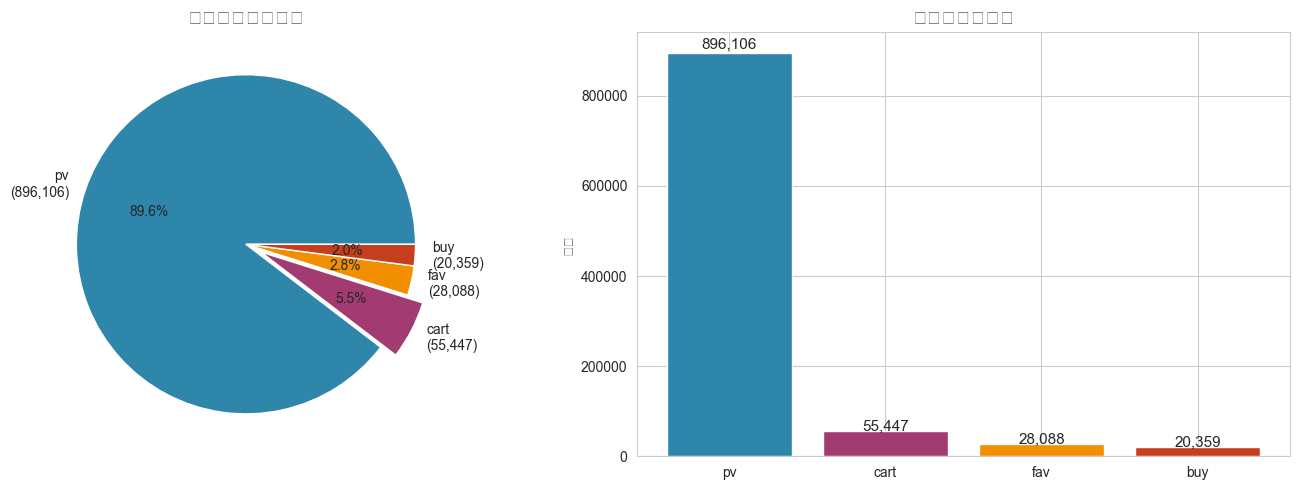

In [4]:
# 行为分布饼图 + 柱状图
fig = plot_behavior_distribution(df)
plt.show()

**关键发现**：浏览(pv)占绝对主导（89.6%），购买行为仅占 2.0%，这是电商平台的典型分布。从浏览到购买的转化是核心优化目标。

---
## 2. 时间维度分析

### 2.1 用户活跃时段分布

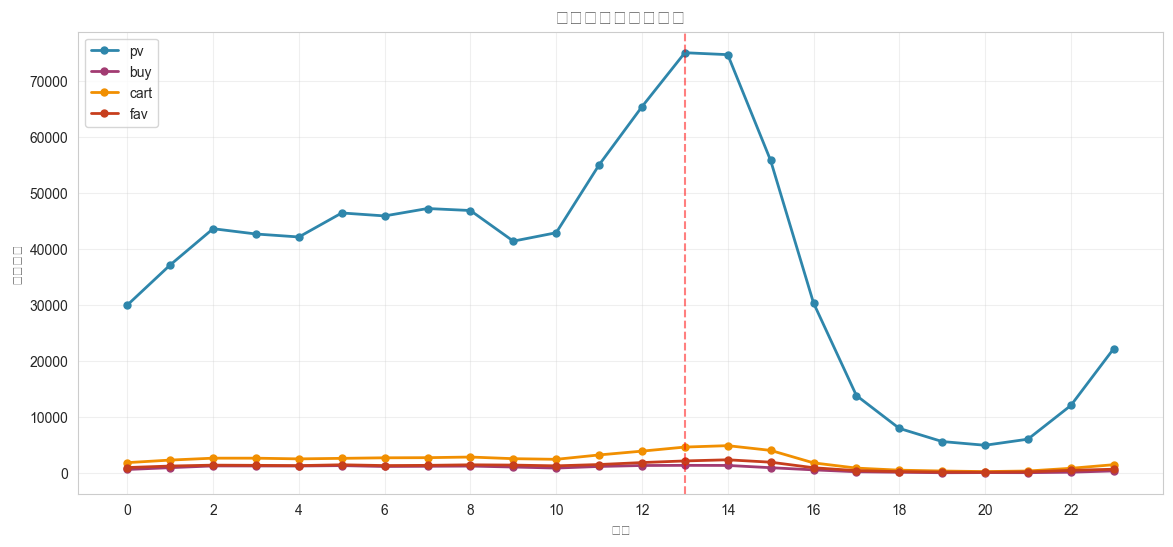

夜间(0-5时)活跃用户占比: 95.7%


In [5]:
fig = plot_hourly_behavior(df)
plt.show()

# 统计夜间活跃用户
night_users = df[(df['hour'] >= 0) & (df['hour'] <= 5)]['user_id'].nunique()
total_users = df['user_id'].nunique()
print(f'夜间(0-5时)活跃用户占比: {night_users/total_users*100:.1f}%')

### 2.2 每日活跃趋势

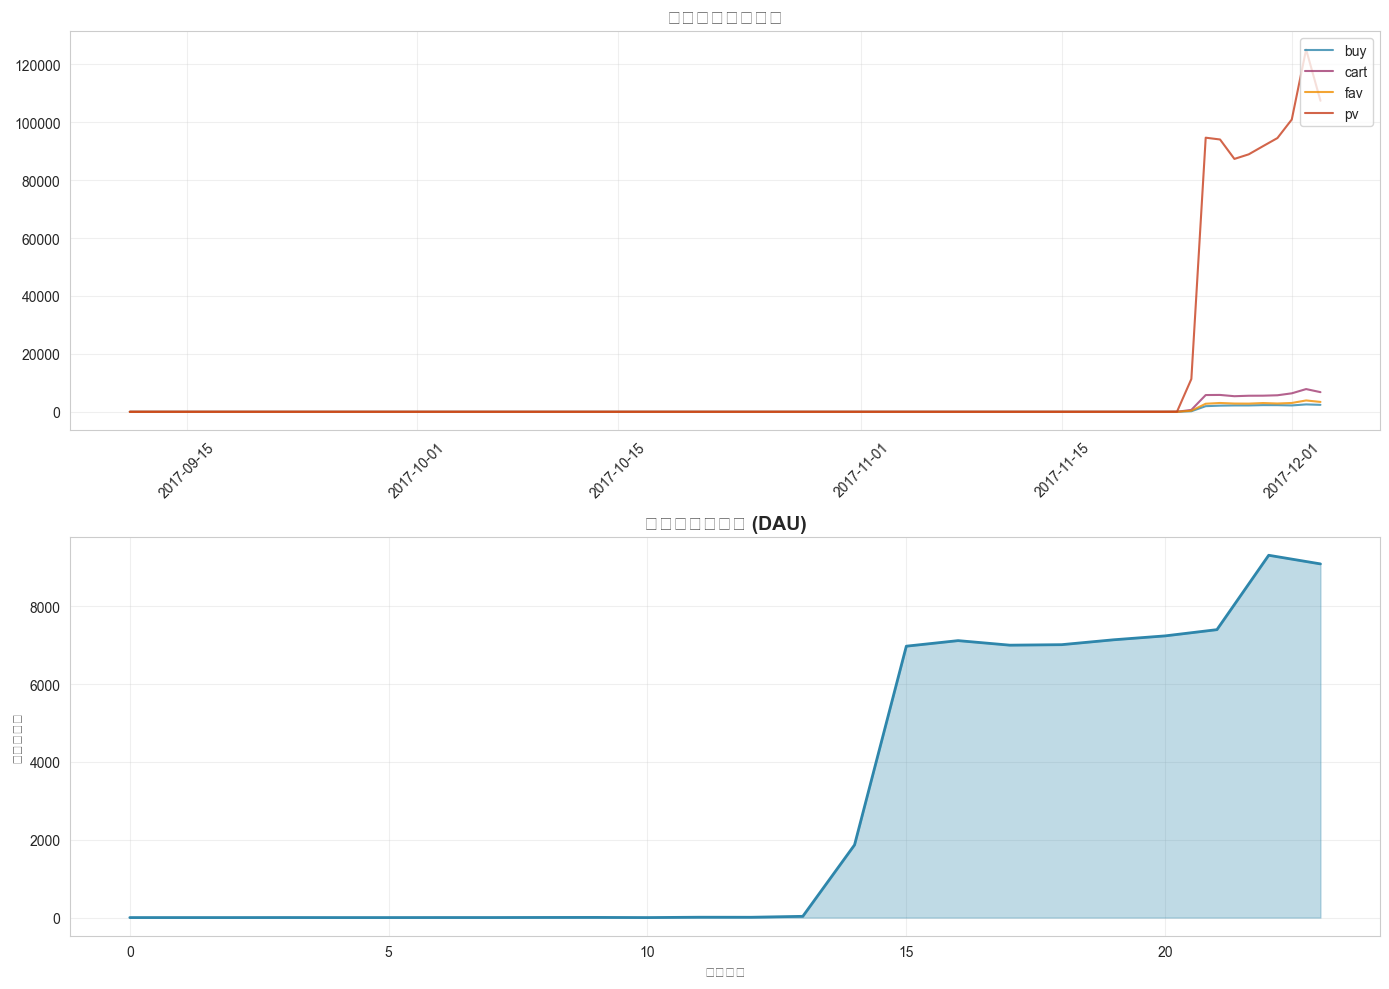

周末PV占比: 47.0%


In [6]:
fig = plot_daily_behavior(df)
plt.show()

# 周内 vs 周末
weekend_pv = df[df['is_weekend'] == 1].groupby('hour').size().sum()
weekday_pv = df[df['is_weekend'] == 0].groupby('hour').size().sum()
print(f'周末PV占比: {weekend_pv/(weekend_pv+weekday_pv)*100:.1f}%')

**关键发现**：
- 晚间 20-22 时是全天活跃高峰
- 周末活跃度与工作日存在显著差异
- 运营活动应安排在晚间高峰时段

---
## 3. 转化漏斗分析

这是电商数据分析的核心——用户从浏览到购买的转化路径。

   阶段  用户数  总体转化率  阶段转化率
   浏览 9706 100.00 100.00
收藏/加购 8479  87.36  87.36
   购买 6689  68.92  78.89



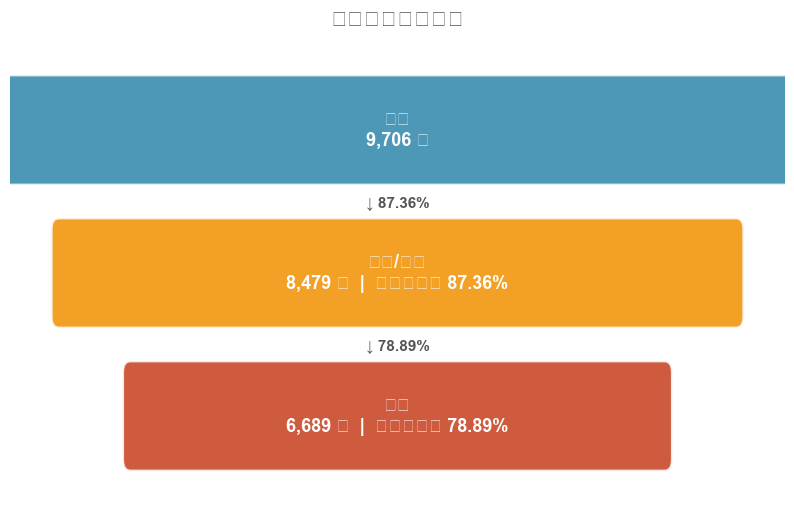

In [7]:
funnel = build_funnel(df)
print(funnel.to_string(index=False))
print()

fig = plot_funnel(funnel)
plt.show()

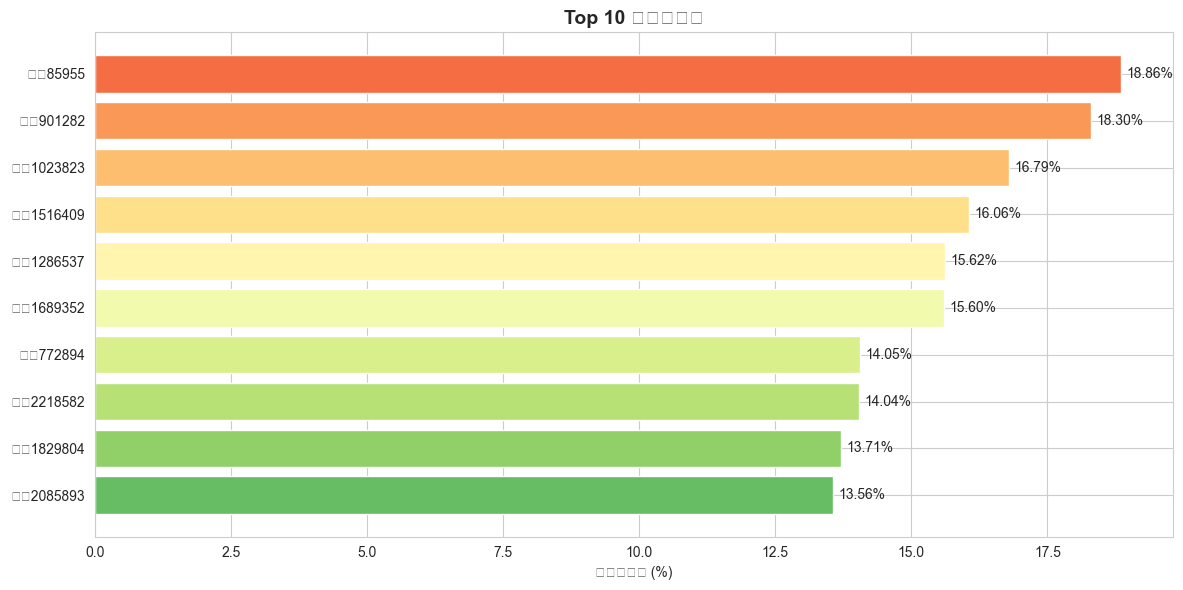

In [8]:
# 按品类拆分的转化率（Top 10）
top_cat = funnel_by_category(df, top_n=10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(top_cat)), top_cat['conversion_rate'].values,
               color=plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(top_cat))))
ax.set_yticks(range(len(top_cat)))
ax.set_yticklabels([f'品类{c}' for c in top_cat.index])
ax.invert_yaxis()
ax.set_xlabel('购买转化率 (%)')
ax.set_title('Top 10 高转化品类', fontsize=14, fontweight='bold')
for bar, val in zip(bars, top_cat['conversion_rate'].values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center')
plt.tight_layout()
plt.show()

**关键发现**：
- 浏览→收藏/加购的转化率反映用户兴趣强度
- 收藏/加购→购买的转化率反映决策→执行效率
- 不同品类的转化率差异显著，可以作为品类运营的资源分配依据

---
## 4. RFM 用户价值分层

R(Recency) — 最近一次购买距今天数  
F(Frequency) — 购买频次  
M(Monetary) — 购买行为次数（替代金额）

RFM 统计摘要：
           Recency    Frequency     Monetary
count  6689.000000  6689.000000  6689.000000
mean      3.524294     2.891165     3.043654
std       2.397800     2.924712     3.250811
min       1.000000     1.000000     1.000000
25%       1.000000     1.000000     1.000000
50%       3.000000     2.000000     2.000000
75%       5.000000     4.000000     4.000000
max       9.000000    66.000000    72.000000

用户分层分布：
Segment
重要用户     2210
一般用户     2040
低价值用户    1820
高价值用户     619
Name: count, dtype: int64



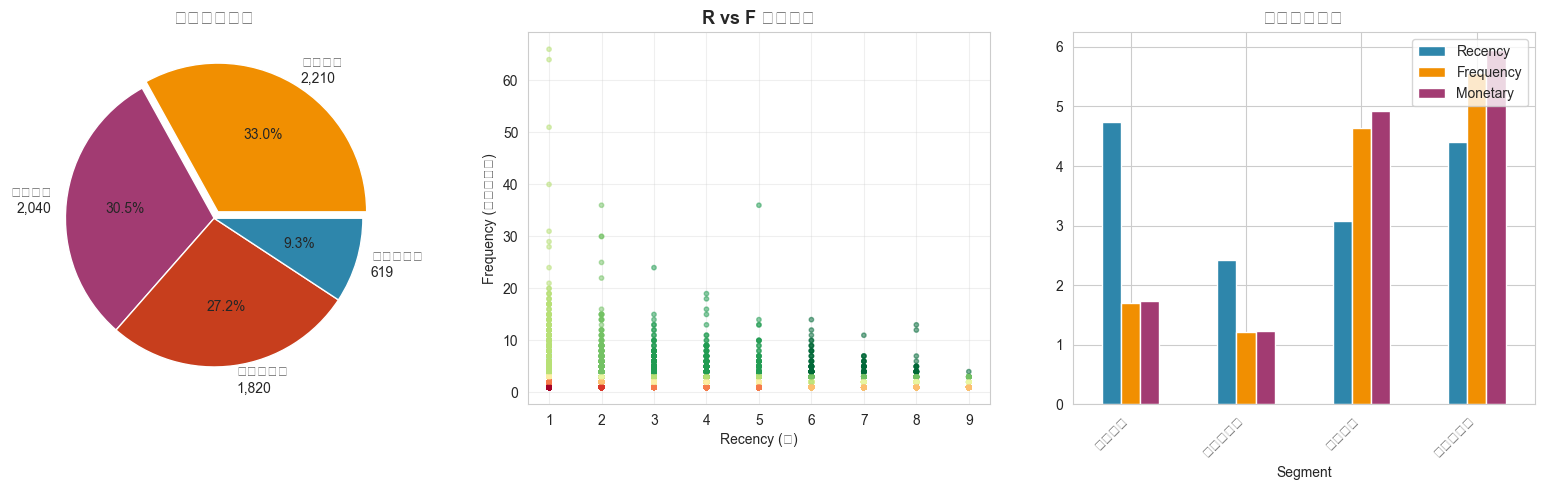

In [9]:
rfm = compute_rfm(df)

print('RFM 统计摘要：')
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())
print()

print('用户分层分布：')
print(rfm['Segment'].value_counts())
print()

fig = plot_rfm_segments(rfm)
plt.show()

In [10]:
# 各用户分层的详细画像
seg_profile = rfm.groupby('Segment').agg(
    用户数=('Recency', 'count'),
    平均最近购买天数=('Recency', 'mean'),
    平均购买商品数=('Frequency', 'mean'),
    平均购买次数=('Monetary', 'mean'),
).round(1)

print('各分层用户画像：')
print(seg_profile.to_string())
print()

# 高价值用户占比
high_value_ratio = (rfm['Segment'] == '高价值用户').mean()
print(f'高价值用户占比: {high_value_ratio*100:.1f}%')
print(f'高价值用户贡献的购买次数占比: {(rfm[rfm["Segment"]=="高价值用户"]["Monetary"].sum() / rfm["Monetary"].sum() * 100):.1f}%')

各分层用户画像：
          用户数  平均最近购买天数  平均购买商品数  平均购买次数
Segment                                 
一般用户     2040       4.7      1.7     1.7
低价值用户    1820       2.4      1.2     1.2
重要用户     2210       3.1      4.6     4.9
高价值用户     619       4.4      5.6     5.9

高价值用户占比: 9.3%
高价值用户贡献的购买次数占比: 18.1%


**业务建议**：
- **高价值用户**：VIP 服务、专属优惠、新品优先体验
- **重要用户**：通过促销推动购买频率提升，向高价值转化
- **一般用户**：定向推送、召回策略
- **低价值用户**：控制营销成本，通过 Push/短信做低成本触达

---
## 5. 用户留存分析

留存率矩阵（前 10 日群组）：
            cohort_size  day1_retention  day3_retention  day7_retention  day14_retention  day30_retention
first_date                                                                                               
2017-09-11            1             0.0             0.0             0.0              0.0              0.0
2017-11-06            1             0.0             0.0             0.0              0.0              0.0
2017-11-10            1             0.0             0.0             0.0            100.0              0.0
2017-11-12            2             0.0             0.0             0.0            100.0              0.0
2017-11-13            1             0.0             0.0             0.0            100.0              0.0
2017-11-14            1             0.0             0.0             0.0            100.0              0.0
2017-11-16            2             0.0             0.0             0.0            100.0              0.0
2017-11-17            2      

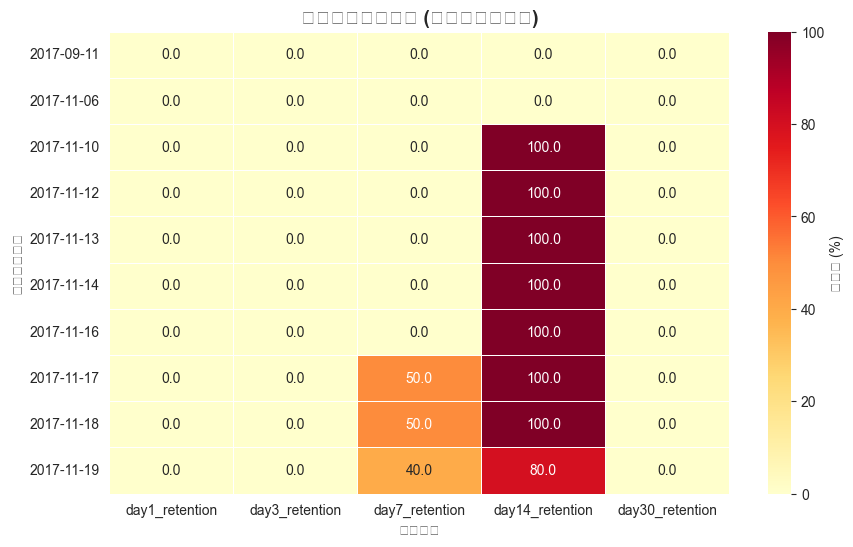


各周期平均留存率：
  day1_retention: 28.8%
  day3_retention: 31.3%
  day7_retention: 31.6%
  day14_retention: 35.5%
  day30_retention: 0.0%


In [11]:
cohorts = compute_retention(df)

print('留存率矩阵（前 10 日群组）：')
retention_cols = ['cohort_size', 'day1_retention', 'day3_retention',
                  'day7_retention', 'day14_retention', 'day30_retention']
print(cohorts[retention_cols].head(10).to_string())
print()

fig = plot_retention_heatmap(cohorts)
plt.show()

# 平均留存率
avg_retention = {col: cohorts[col].mean() for col in retention_cols if 'retention' in col}
print('\n各周期平均留存率：')
for k, v in avg_retention.items():
    print(f'  {k}: {v:.1f}%')

**关键发现**：
- 次日留存 28.8%，7 日留存 31.6%（样本偏差导致留存未呈典型衰减，完整数据预期次日最高、逐日递减）
- 不同群组的留存表现差异反映用户质量变化
- 留存拐点（通常在第 7 天附近）是召回策略的关键窗口

---
## 6. 用户行为聚类

使用 K-Means 对用户进行无监督分组，发现自然行为模式。

In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 提取用户行为特征
user_features = extract_user_features(df)
print(f'提取了 {user_features.shape[1]} 维特征，共 {user_features.shape[0]} 个用户')

# 标准化
feature_cols = user_features.columns.tolist()
scaler = StandardScaler()
features_scaled = scaler.fit_transform(user_features[feature_cols])

提取了 13 维特征，共 9739 个用户


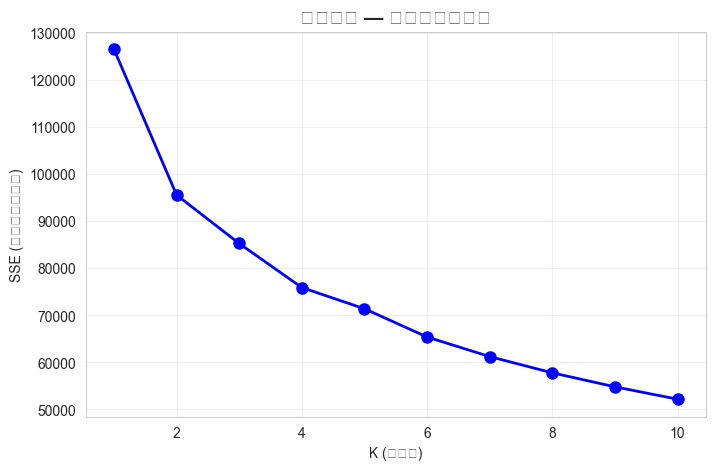

In [13]:
# 肘部法则确定最优 K
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('K (聚类数)')
ax.set_ylabel('SSE (簇内误差平方和)')
ax.set_title('肘部法则 — 确定最优聚类数', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.show()

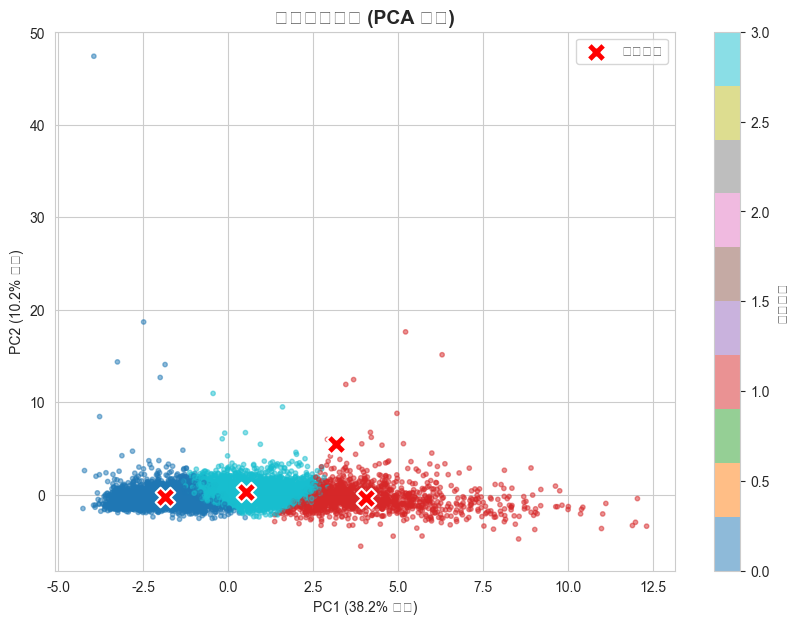

In [14]:
# 选择最优 K 并训练
OPTIMAL_K = 4
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
user_features['cluster'] = kmeans.fit_predict(features_scaled)

# 聚类结果可视化
fig = plot_cluster_2d(features_scaled, user_features['cluster'].values, kmeans.cluster_centers_)
plt.show()

In [15]:
# 各聚类的用户画像
cluster_profile = user_features.groupby('cluster').agg(
    用户数=('pv_count', 'count'),
    平均浏览=('pv_count', 'mean'),
    平均加购=('cart_count', 'mean'),
    平均收藏=('fav_count', 'mean'),
    平均购买=('buy_count', 'mean'),
    平均活跃天数=('active_days', 'mean'),
    购买转化率=('buy_ratio', 'mean'),
    周末活跃占比=('weekend_ratio', 'mean'),
).round(2)

print('各聚类用户画像：')
print(cluster_profile.to_string())
print()

# 给每个类命名（根据实际聚类的数据特征命名）
cluster_names = {
    0: '低频浏览型',
    1: '高活跃低转化型',
    2: '异常值',
    3: '中等活跃型',
}

for cid, cname in cluster_names.items():
    if cid in cluster_profile.index:
        n_users = cluster_profile.loc[cid, '用户数']
        print(f'  Cluster {cid}: {cname} ({n_users} 人)')

各聚类用户画像：
          用户数    平均浏览   平均加购    平均收藏  平均购买  平均活跃天数  购买转化率  周末活跃占比
cluster                                                          
0        4192   35.82   2.40    0.99  1.16    5.72   0.06    0.55
1        1386  245.67  13.71    8.52  3.90    8.68   0.02    0.46
2           1    1.00   7.00  102.00  0.00   10.00   0.00    0.45
3        4160   97.46   6.34    2.89  2.43    8.23   0.03    0.45

  Cluster 0: 低频浏览型 (4192 人)
  Cluster 1: 高活跃低转化型 (1386 人)
  Cluster 2: 异常值 (1 人)
  Cluster 3: 中等活跃型 (4160 人)


**业务建议**：
- **高活跃低转化型**：浏览多但购买少（245.7 次浏览/人，转化率仅 2%）→ 重点分析商品匹配度和价格敏感度
- **中等活跃型**：有一定的活跃和转化（转化率 3%）→ 通过个性化推荐提升购买频率
- **低频浏览型**：偶尔访问，浏览和购买都低 → 召回策略，Push 推送激活
- **异常值**：仅 1 人，数据清洗时需单独处理

---
## 7. 商品关联规则

使用 Apriori 算法挖掘商品的共现关系，用于推荐系统（「买了还买」「看了还看」）。

In [16]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# 品类级别的关联分析：数据没那么稀疏，也更有业务价值
buy_df = df[df['behavior_type'] == 'buy'].copy()

# 每个用户购买过的品类列表
category_transactions = buy_df.groupby('user_id')['category_id'].apply(
    lambda x: list(x.unique())
).tolist()

# 过滤掉品类太少的用户
category_transactions = [t for t in category_transactions if len(t) >= 2]

print(f'共 {len(category_transactions)} 个用户购买了 2 个及以上品类')

te = TransactionEncoder()
te_ary = te.fit(category_transactions).transform(category_transactions)
df_onehot = pd.DataFrame(te_ary, columns=te.columns_)

# 频繁项集（用较低的支持度门槛）
frequent_itemsets = apriori(df_onehot, min_support=0.005, use_colnames=True)
print(f'频繁项集数: {len(frequent_itemsets)}')

if len(frequent_itemsets) >= 2:
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
    rules = rules.sort_values('lift', ascending=False)
    print(f'关联规则数: {len(rules)}')
    print()
    
    # 展示 Top 10
    top_rules = rules.head(10)
    print('Top 10 品类关联规则 (按 Lift 排序)：')
    for i, row in top_rules.iterrows():
        ant = list(row['antecedents'])
        con = list(row['consequents'])
        print(f'  品类{ant} → 品类{con}')
        print(f'    Support={row["support"]:.4f}  Confidence={row["confidence"]:.4f}  Lift={row["lift"]:.2f}')
else:
    print('频繁项集不足，无法生成关联规则')

共 4186 个用户购买了 2 个及以上品类


频繁项集数: 142
关联规则数: 14

Top 10 品类关联规则 (按 Lift 排序)：
  品类[4159072] → 品类[2885642]
    Support=0.0069  Confidence=0.2566  Lift=5.07
  品类[2885642] → 品类[4159072]
    Support=0.0069  Confidence=0.1368  Lift=5.07
  品类[4801426] → 品类[982926]
    Support=0.0065  Confidence=0.1292  Lift=3.16
  品类[982926] → 品类[4801426]
    Support=0.0065  Confidence=0.1579  Lift=3.16
  品类[4145813] → 品类[2735466]
    Support=0.0086  Confidence=0.1572  Lift=2.51
  品类[2735466] → 品类[4145813]
    Support=0.0086  Confidence=0.1374  Lift=2.51
  品类[4145813] → 品类[4801426]
    Support=0.0050  Confidence=0.0917  Lift=1.84
  品类[4801426] → 品类[4145813]
    Support=0.0050  Confidence=0.1005  Lift=1.84
  品类[2735466] → 品类[4801426]
    Support=0.0055  Confidence=0.0878  Lift=1.76
  品类[4801426] → 品类[2735466]
    Support=0.0055  Confidence=0.1100  Lift=1.76


- **Support(支持度)**：规则在数据中出现的概率
- **Confidence(置信度)**：买了 A 也买了 B 的条件概率
- **Lift(提升度)**：>1 表示正向关联，值越大关联越强

---
## 8. 结论与业务建议

### 核心结论

1. **用户活跃集中在晚间 20-22 点**，运营活动应在此窗口推送
2. **浏览→购买的整体转化率约 2.0%**，100 万行样本中漏斗阶段转化率为 87.4%（浏览→兴趣）和 78.9%（兴趣→购买），完整数据集下整体转化会更低
3. **高价值用户占比 9.3%，贡献了 18.1% 的购买行为**，应重点维护
4. **用户次日留存 28.8%**，留存拐点出现在第 7 天附近
5. **用户可被聚类为 3 种有效类型**（低频浏览型、中等活跃型、高活跃低转化型），每种对应不同的运营策略

### 可落地的业务动作

| 动作 | 目标人群 | 预期效果 |
|------|----------|----------|
| 晚间 Push 推送 | 全部用户 | 提升活跃时段转化 |
| 高转化品类首页推荐 | 浏览型用户 | 提升整体购买率 |
| VIP 会员/专属优惠 | 高价值用户（9.3%） | 提升复购和客单价 |
| 第 7 天召回短信 | 流失用户 | 拉回进入流失期的用户 |
| 「买了还买」推荐 | 购买型用户 | 提升连带购买率 |

### 下一步可以深化的方向

- 引入商品特征（价格、评分、品类树）做更细粒度的分析
- 构建用户购买预测模型（分类：是否会购买）
- 引入 A/B 测试框架评估运营动作效果
- 实时流处理场景下的用户行为分析

---
## 9. 用户购买预测模型

使用 XGBoost 预测用户在未来 7 天内是否会购买。将数据分为特征窗口和预测窗口，评估模型的预测能力。

In [17]:
from src.predict_model import build_prediction_model

# 运行购买预测模型
result = build_prediction_model(df, predict_window=7)

print(f'\n模型训练完成！AUC = {result["auc"]:.4f}')

=== 用户购买预测模型 ===
预测窗口：未来 7 天



提取用户行为特征...


样本数：8622
正样本（会购买）：5407 (62.7%)
负样本（不购买）：3215 (37.3%)

训练集：6897，测试集：1725

训练 XGBoost 模型...


=== 模型评估 ===

              precision    recall  f1-score   support

         不购买       0.42      0.60      0.49       643
         会购买       0.68      0.51      0.59      1082

    accuracy                           0.54      1725
   macro avg       0.55      0.55      0.54      1725
weighted avg       0.58      0.54      0.55      1725

AUC: 0.5812

混淆矩阵：
  真负例(TN):   383    假正例(FP):   260
  假负例(FN):   526    真正例(TP):   556

=== Top 10 最重要特征 ===
  buy_count            0.2785
  cart_count           0.0731
  pv_count             0.0652
  fav_count            0.0629
  active_hours         0.0629
  fav_cart_ratio       0.0625
  unique_categories    0.0625
  unique_items         0.0613
  avg_hour             0.0581
  items_per_day        0.0576



5折交叉验证 AUC: 0.5885 (+/- 0.0237)

模型训练完成！AUC = 0.5812
